# CPU Benchmark Analysis — Data Loading & Exploration

This notebook is the starting point of the project. Before any modeling or
analysis can be done, we need to understand the data we are working with.

We have two datasets sourced from Kaggle — one containing PassMark benchmark
results for 3,825 CPUs, and another containing Cinebench R23 scores for 215 CPUs.

The goal of this notebook is to:
- Load both datasets and understand their structure
- Document what each column represents
- Check whether the two datasets can be meaningfully combined
- Identify any data quality issues such as missing values or inconsistencies

No cleaning or modeling is done here. This notebook is purely about
getting familiar with the data before making any decisions.

------

In [1]:
# Mount Google Drive to access project files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Define the path to the project folder in Google Drive
import pandas as pd

path = '/content/drive/MyDrive/CPU Project/'

# Load both datasets
df_bench = pd.read_csv(path + 'CPU_benchmark_v4.csv')
df_r23 = pd.read_csv(path + 'CPU_r23_v2.csv')

In [3]:
# Inspect the shape and column names of both datasets
# This tells us what we're working with before doing anything else

print(" CPU_benchmark_v4 ")
print("Shape:", df_bench.shape)
print("Columns:", df_bench.columns.tolist())

print("\n CPU_r23_v2 ")
print("Shape:", df_r23.shape)
print("Columns:", df_r23.columns.tolist())

 CPU_benchmark_v4 
Shape: (3825, 12)
Columns: ['cpuName', 'price', 'cpuMark', 'cpuValue', 'threadMark', 'threadValue', 'TDP', 'powerPerf', 'cores', 'testDate', 'socket', 'category']

 CPU_r23_v2 
Shape: (215, 9)
Columns: ['manufacturer', 'cpuName', 'singleScore', 'multiScore', 'cores', 'threads', 'baseClock', 'turboClock', 'type']


--------

### Dataset 1: CPU_benchmark_v4

Shape: 3,825 rows, 12 columns
Source: PassMark Performance Test

This dataset contains PassMark benchmark results for a wide range of CPUs.

`cpuMark` is the multi-thread CPU Mark score and will serve as our target
variable — it measures how well a CPU performs across all its cores simultaneously.

`threadMark` is the single-thread CPU Mark score, which reflects how fast
a CPU runs a single task. This is important because many real-world applications
depend more on single-thread performance than multi-thread.

`cpuValue` and `threadValue` are derived metrics — they divide the respective
benchmark scores by price, giving a measure of performance per dollar.
`powerPerf` follows the same idea but divides `cpuMark` by `TDP` (thermal design
power in watts), giving a measure of performance per watt.

`price` is the last recorded market price in USD. `cores` is the number of
physical cores. `socket` refers to the CPU socket type, and `category` tells
us the CPU's use case segment. `testDate` is the date of the first benchmark
submission for that CPU.

-------

In [4]:
# Inspect the first few rows of the R23 dataset
# Since there is no official documentation, we read the data itself to understand each column

df_r23.head(10)

,manufacturer,cpuName,singleScore,multiScore,cores,threads,baseClock,turboClock,type
0,AMD,Threadripper 3990X,1262,75671,64,128,2.9,4.50,Desktop
1,AMD,Threadripper Pro 3995WX,1231,73220,64,128,2.7,4.20,Desktop
2,AMD,Epyc 7702P,993,48959,64,128,2.0,3.35,Desktop
3,AMD,Threadripper 3970X,1308,46874,32,64,3.7,4.50,Desktop
4,AMD,Threadripper Pro 3975WX,1244,43450,32,64,3.5,4.20,Desktop
5,AMD,Threadripper 3960X,1307,34932,24,64,3.8,4.50,Desktop
6,AMD,Threadripper 2990WX,1005,29651,32,64,3.0,4.20,Desktop
7,AMD,Ryzen 9 5950X,1684,28782,16,32,3.4,4.90,Desktop
8,Intel,Core i9 12900K,2007,27852,16,24,3.2,5.20,Desktop
9,Intel,Core i9 12900KF,1974,27852,16,24,3.2,5.20,Desktop


### Dataset 2: CPU_r23_v2

Shape: 215 rows, 9 columns
Source: Cinebench R23

This dataset contains Cinebench R23 benchmark results for 215 CPUs from
Intel and AMD. Cinebench R23 is a rendering benchmark that tests CPU
performance using the Cinema 4D engine.

`singleScore` measures single-core rendering performance and `multiScore`
measures multi-core rendering performance — both are raw Cinebench R23 scores.

`cores` and `threads` describe the CPU's physical and logical processor count.
`baseClock` is the default operating frequency in GHz and `turboClock` is the
maximum boost frequency in GHz. `manufacturer` identifies the brand and
`type` tells us whether the CPU is a Desktop or Laptop chip.

------

### Initial Observations

Before writing any code, a few things are worth noting from just looking
at the two datasets side by side.

The main dataset has 3,825 CPUs while the R23 dataset only has 215. This is
a significant size difference. Both files share `cpuName` and `cores` as
common columns, which means a merge is technically possible.

However, the R23 dataset has columns that the main dataset is missing —
specifically `threads`, `baseClock`, and `turboClock`. These are useful
hardware specs that could improve our model later. The question is whether
enough CPUs overlap between the two files to make a merge worthwhile.

We check that in the next section.

## Overlap Check

In [5]:
# Before deciding whether to merge, we check how many CPU names
# appear in both datasets. A low overlap means merging would
# significantly reduce our data and may not be worth it.

overlap = set(df_bench['cpuName']).intersection(set(df_r23['cpuName']))

print("OVERLAP ANALYSIS")
print(f"Unique CPUs in benchmark file : {df_bench['cpuName'].nunique()}")
print(f"Unique CPUs in R23 file       : {df_r23['cpuName'].nunique()}")
print(f"CPUs found in both files      : {len(overlap)}")
print(f"Overlap percentage            : {round(len(overlap) / df_r23['cpuName'].nunique() * 100, 1)}%")

OVERLAP ANALYSIS
Unique CPUs in benchmark file : 3825
Unique CPUs in R23 file       : 215
CPUs found in both files      : 0
Overlap percentage            : 0.0%


## Why Is the Overlap Zero?

Running an exact match on `cpuName` between both files returned zero overlapping CPUs.
Before concluding that the two datasets share no common CPUs, we need to investigate why.

A zero overlap on CPU names almost always points to a naming inconsistency rather than
truly different CPUs. For example, one file might store a CPU as "Intel Core i9-12900K"
while the other stores the same CPU as "Core i9 12900K" — same hardware, different format.

We look at a sample of names from each file side by side to confirm this.

In [6]:
# Zero overlap likely means naming inconsistencies rather than truly different CPUs
# We compare a few names from each file side by side to investigate

print("Sample names from benchmark file:")
print(df_bench['cpuName'].head(10).tolist())

print()

print("Sample names from R23 file:")
print(df_r23['cpuName'].head(10).tolist())

Sample names from benchmark file:
['AMD Ryzen Threadripper PRO 5995WX', 'AMD EPYC 7763', 'AMD EPYC 7J13', 'AMD EPYC 7713', 'AMD Ryzen Threadripper PRO 3995WX', 'AMD Ryzen Threadripper 3990X', 'AMD Ryzen Threadripper PRO 5975WX', 'AMD EPYC 7B13', 'AMD EPYC 7643', 'AMD EPYC 7702']

Sample names from R23 file:
['Threadripper 3990X', 'Threadripper Pro 3995WX', 'Epyc 7702P', 'Threadripper 3970X', 'Threadripper Pro 3975WX', 'Threadripper 3960X', 'Threadripper 2990WX', 'Ryzen 9 5950X', 'Core i9 12900K', 'Core i9 12900KF']


### Findings

The zero overlap is caused by inconsistent naming conventions between the two files.
The benchmark file uses full names like "AMD Ryzen Threadripper 3990X" while the R23
file shortens them to "Threadripper 3990X".

A merge is technically possible using partial string matching, but it would reduce
our dataset from 3,825 rows down to at most 215 rows — a loss of roughly 94% of our data.

Given that our goal is to predict `cpuMark` from hardware specs, losing that much data
would hurt our model far more than gaining three extra columns would help it.

The decision is to work with `CPU_benchmark_v4` as our primary dataset and treat
`CPU_r23_v2` as a supplementary reference only.

-----

## Project Goal

The goal of this project is to predict a CPU's PassMark multi-thread benchmark
score (`cpuMark`) using its hardware specifications.

A CPU's benchmark score is only known after someone physically runs the test.
However, specs like cores, TDP, and price are published the moment a CPU is
announced. We use these specs to train a model that can estimate `cpuMark`
before any benchmark is run.

This is a regression problem — we are predicting a continuous number, not a category.

------

## Exploratory Data Analysis

Now that we understand what we are working with, we begin exploring the main dataset.
The goal here is not to clean or model anything yet — it is to understand the shape
of the data, spot any quality issues, and get a feel for how the columns relate to
each other.

We start with three basic questions:
- What are the data types of each column?
- Are there any missing values?
- What does the distribution of our target variable look like?

In [7]:
# A concise summary of the dataset
# Shows data types, non-null counts, and memory usage

df_bench.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3825 entries, 0 to 3824
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   cpuName      3825 non-null   object 
 1   price        1967 non-null   float64
 2   cpuMark      3825 non-null   int64  
 3   cpuValue     1967 non-null   float64
 4   threadMark   3825 non-null   int64  
 5   threadValue  1967 non-null   float64
 6   TDP          3140 non-null   float64
 7   powerPerf    3140 non-null   object 
 8   cores        3825 non-null   int64  
 9   testDate     3825 non-null   int64  
 10  socket       3825 non-null   object 
 11  category     3825 non-null   object 
dtypes: float64(4), int64(4), object(4)
memory usage: 358.7+ KB


### Data Types and Missing Values

Running `df_bench.info()` reveals a few important issues.

Missing values are most severe in `price`, `cpuValue`, and `threadValue` where
roughly 49% of rows have no value. `TDP` and `powerPerf` are missing about 18%
of their values. Our target variable `cpuMark` has no missing values which is
good news for modeling.

Two columns have data type issues worth investigating. `powerPerf` is stored as
an object instead of a float — this suggests there may be non-numeric characters
hiding in that column. `testDate` is stored as an integer which is unusual for
a date column — we need to look at the actual values to understand the format.

These issues will be addressed in the data cleaning phase.

----

In [8]:
# Check the percentage of missing values per column
# Helps us prioritize which columns need attention

missing = df_bench.isnull().sum()
missing_pct = (missing / len(df_bench) * 100).round(1)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
})

print(missing_df[missing_df['missing_count'] > 0])

             missing_count  missing_pct
price                 1858         48.6
cpuValue              1858         48.6
threadValue           1858         48.6
TDP                    685         17.9
powerPerf              685         17.9


### Missing Value Patterns

The missing values follow a clear pattern.

`price`, `cpuValue`, and `threadValue` all have exactly 1,858 missing rows — 48.6%.
This is not a coincidence. `cpuValue` and `threadValue` are derived directly from
`price`, so wherever `price` is missing those two columns are automatically missing as well.

Similarly, `TDP` and `powerPerf` share exactly 685 missing rows — 17.9%.
`powerPerf` is calculated from `TDP`, so the same logic applies.

This means we effectively have two missing value problems, not five:
- `price` is missing for 48.6% of CPUs
- `TDP` is missing for 17.9% of CPUs

How we handle these will be decided in the data cleaning phase.

----

In [9]:
# Investigate powerPerf — stored as object instead of float
# We look at a sample of values to spot any non-numeric characters

print("Sample powerPerf values:")
print(df_bench['powerPerf'].dropna().head(10).tolist())

print()

# Investigate testDate — stored as integer instead of a date
print("Sample testDate values:")
print(df_bench['testDate'].head(10).tolist())

Sample powerPerf values:
['388.65', '315.49', '381.6', '299.9', '291.31', '288.72', '339.8', '358.23', '318.12', '305.55']

Sample testDate values:
[2022, 2021, 2021, 2021, 2020, 2020, 2022, 2021, 2021, 2020]


### Investigating Suspicious Columns

Looking at the actual values in both columns clarifies the issues flagged earlier.

`powerPerf` contains numeric values but they are stored as strings, which is why
pandas read the column as object type instead of float. There are no corrupted
values — it simply needs to be converted to a numeric type.

`testDate` is not a full date — it only contains the year the benchmark was first
submitted. This explains why it was stored as an integer. It is not broken,
just simpler than expected. We will treat it as a numeric feature rather than
a datetime column.

-----

In [10]:
# A quick look at the unique categories and socket types
# This tells us what kind of categorical variables we are dealing with

print("Unique categories:")
print(df_bench['category'].unique())

print()

print("Unique socket types:")
print(df_bench['socket'].unique())

Unique categories:
['Desktop' 'Server' 'Desktop, Server' 'Unknown' 'Laptop' 'Laptop, Server'
 'Desktop, Laptop' 'Desktop, Mobile/Embedded' 'Server, Mobile/Embedded'
 'Mobile/Embedded' 'Laptop, Mobile/Embedded'
 'Desktop, Laptop, Mobile/Embedded']

Unique socket types:
['sWRX8' 'SP3' 'unknown' 'sTRX4' 'FCLGA4189' 'LGA4189' 'AM4' 'LGA 1700'
 'FCLGA1700' 'FCLGA3647' 'LGA3647' 'FCBGA2579' 'FCLGA2066' 'sTR4'
 'LGA 3647' 'FCBGA1744' 'LGA2066' 'TR4' 'FCLGA1200' 'FCLGA2011-3' 'FP7'
 'FCLGA-2066' 'FCBGA1787' 'LGA2011-v3' 'FP6' 'BGA1700' 'FCLGA1151-2'
 'FCLGA-3647' 'FCBGA2518' 'LGA2011-1' 'FCBGA1440' 'FCLGA2011' 'LGA2011'
 'SP4r2' 'LGA 2011' 'FCBGA1449' 'FCBGA1667' 'BGA1744' 'BGA1526' 'LGA 1356'
 'FCBGA1598' 'FCBGA1528' 'FCBGA1344' 'BGA 1449' 'LGA 1151' 'FCLGA1151'
 'FCBGA2227' 'LGA1151' 'BGA2270' 'FCBGA-1526' 'FP5' 'FCBGA1526'
 'Socket G34' 'LGA1150' 'FCLGA1150' 'FCBGA1364' 'LGA1366'
 'FPGA946,FPGA947' 'G34' 'LGA1700,BGA1700' 'AM3+' 'FCPGA946' 'LGA1155'
 'FCLGA1356' 'FCBGA1356' 'FC-BGA1356' 'rP

### Categorical Column Investigation

Looking at the unique values in `category` and `socket` reveals two data quality issues.

`category` contains multi-label values where a single CPU is assigned to more than
one category, such as "Desktop, Server" or "Laptop, Mobile/Embedded". There is also
an "Unknown" value present. This column will need to be simplified before it can be
used in a model.

`socket` has over 150 unique values, many of which represent the same socket type
written in different formats. For example, LGA1700 appears as "LGA 1700", "FCLGA1700",
and "BGA1700". This kind of inconsistency is common in real-world datasets where data
is collected from multiple sources. Standardizing this column will be an important
step in the cleaning phase.

Both columns will be addressed during data cleaning. For now we note the issues
and move on to understanding our target variable.

-----

In [11]:
# Look at the distribution of our target variable
# Understanding how cpuMark is distributed is essential before modeling

print("cpuMark summary statistics:")
print(df_bench['cpuMark'].describe())

cpuMark summary statistics:
count      3825.000000
mean       5992.305882
std        9617.551479
min          77.000000
25%         943.000000
50%        2331.000000
75%        6643.000000
max      108822.000000
Name: cpuMark, dtype: float64


### Target Variable Distribution

The distribution of `cpuMark` is heavily right skewed. The mean score is 5,992
but the median is only 2,331 — meaning half of all CPUs in the dataset score
below 2,331. The maximum value of 108,822 is nearly 47 times the median,
indicating a small number of extremely high performing server and workstation
CPUs are pulling the average up significantly.

This kind of skew is common in hardware benchmarks where most CPUs are consumer
grade and only a handful are high end server chips. A log transformation of the
target variable will likely be needed before modeling to handle this skew.

----

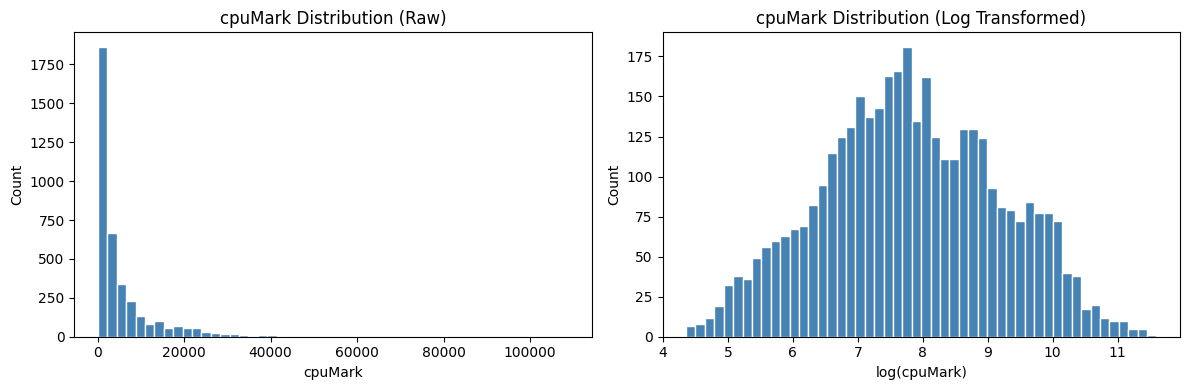

In [12]:
import matplotlib.pyplot as plt

# Visualize the distribution of our target variable
# A histogram helps us see the skew clearly

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw distribution
axes[0].hist(df_bench['cpuMark'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('cpuMark Distribution (Raw)')
axes[0].set_xlabel('cpuMark')
axes[0].set_ylabel('Count')

# Log transformed distribution
import numpy as np
axes[1].hist(np.log1p(df_bench['cpuMark']), bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('cpuMark Distribution (Log Transformed)')
axes[1].set_xlabel('log(cpuMark)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### Target Variable Distribution — Visual Confirmation

The histogram of raw `cpuMark` confirms the right skew clearly. The vast majority
of CPUs cluster near zero on the scale while a small number of server and workstation
chips extend the tail all the way to 108,822.

After applying a log transformation the distribution becomes much more symmetrical
and bell shaped. This confirms that we should log transform `cpuMark` before
modeling. When we make predictions we simply reverse the transformation using
an exponential function to get back to the original scale.

------

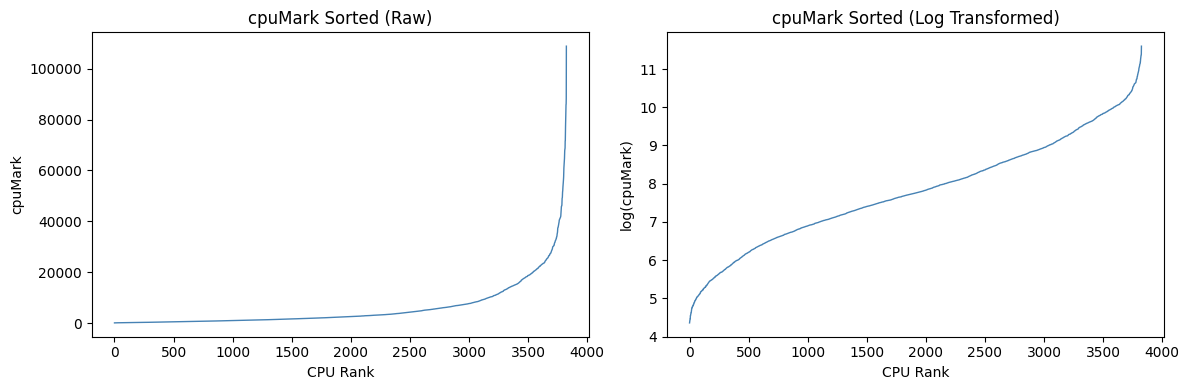

In [13]:
# Line graph of sorted cpuMark values
# Sorting and plotting each CPU's score shows the skew as a curve
# A steep upward curve at the end confirms the presence of extreme outliers

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw sorted values
sorted_marks = df_bench['cpuMark'].sort_values().reset_index(drop=True)
axes[0].plot(sorted_marks, color='steelblue', linewidth=1)
axes[0].set_title('cpuMark Sorted (Raw)')
axes[0].set_xlabel('CPU Rank')
axes[0].set_ylabel('cpuMark')

# Log transformed sorted values
axes[1].plot(np.log1p(sorted_marks), color='steelblue', linewidth=1)
axes[1].set_title('cpuMark Sorted (Log Transformed)')
axes[1].set_xlabel('CPU Rank')
axes[1].set_ylabel('log(cpuMark)')

plt.tight_layout()
plt.show()

### Sorted Value Plot

Plotting each CPU's score in ascending order makes the skew even more visible.

In the raw plot the line stays nearly flat for roughly 3,500 CPUs before shooting
almost vertically upward. This means the top few percent of CPUs have scores so
extreme that the rest of the dataset becomes visually compressed near zero.

The log transformed plot smooths this curve out significantly, confirming that
the transformation is the right approach before modeling.

----------

### Cores vs Benchmark Score

Now that we understand the distribution of our target variable, we explore how
individual features relate to cpuMark. We start with cores since it was identified
as the second most important feature in our model.

The scatter plot below shows each CPU as a single point, with the number of cores
on the x-axis and the benchmark score on the y-axis. Points are colored by category
so we can see how Desktop, Laptop, Server, and Other CPUs cluster differently.

We expect to see a general upward trend — more cores should mean a higher benchmark
score. However the relationship is unlikely to be perfectly linear, and Server CPUs
should dominate the high core count region.

### Loading Cleaned Dataset for Visualization

For the visualizations below we load the cleaned dataset produced in Notebook 2.
This ensures category and socket labels are consistent and properly simplified.

In [15]:
# Load the cleaned dataset for visualizations
df_clean = pd.read_csv(path + 'CPU_benchmark_cleaned.csv')

print("Cleaned dataset loaded")
print(f"Shape: {df_clean.shape}")

Cleaned dataset loaded
Shape: (3825, 9)


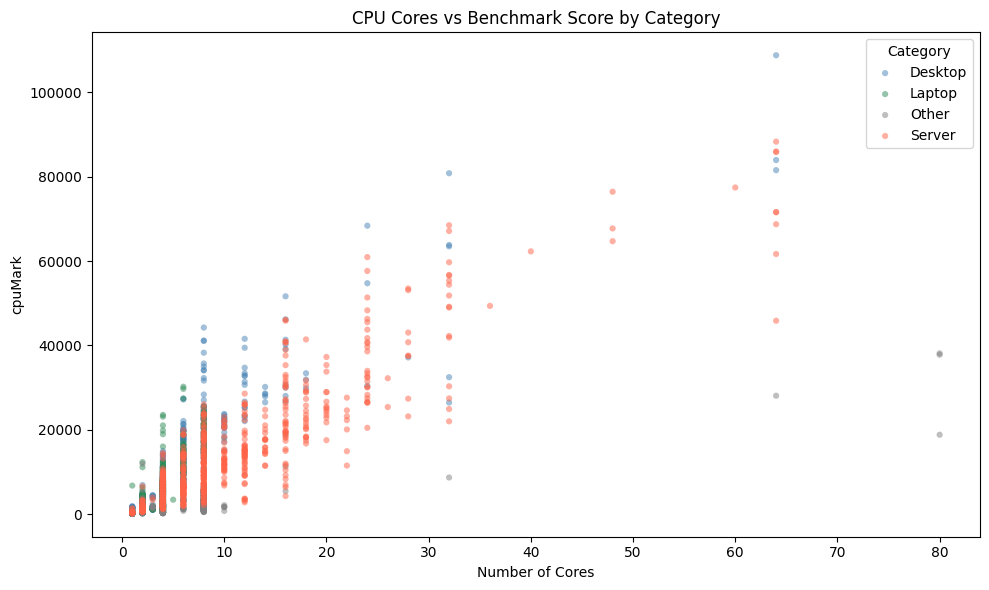

In [16]:
colors = {
    'Desktop' : 'steelblue',
    'Laptop'  : 'seagreen',
    'Server'  : 'tomato',
    'Other'   : 'gray'
}

fig, ax = plt.subplots(figsize=(10, 6))

for category, group in df_clean.groupby('category'):
    ax.scatter(
        group['cores'],
        group['cpuMark'],
        c=colors.get(category, 'gray'),
        label=category,
        alpha=0.5,
        edgecolors='none',
        s=20
    )

ax.set_title('CPU Cores vs Benchmark Score by Category')
ax.set_xlabel('Number of Cores')
ax.set_ylabel('cpuMark')
ax.legend(title='Category')

plt.tight_layout()
plt.show()

### Cores vs Benchmark Score — Findings

The scatter plot confirms a clear positive relationship between core count and
cpuMark. As core count increases benchmark scores generally rise, consistent with
the multi-thread nature of the PassMark test.

Desktop CPUs cluster between 4 and 16 cores while Laptop CPUs are concentrated
at the lower end of the core count range. Server CPUs span the widest range —
from 8 to 64 cores — and consistently achieve the highest benchmark scores at
every core count level.

The vertical spread at each core count confirms that cores alone do not fully
explain benchmark performance. Other features like single thread performance and
price contribute meaningfully, which aligns with the SHAP analysis in Notebook 3.

-----

## Key Findings

This notebook covered the initial loading and exploration of the CPU benchmark dataset.
Before moving to cleaning and modeling, here is a summary of everything we found.

### Data Sources
We loaded two datasets — CPU_benchmark_v4 with 3,825 CPUs and CPU_r23_v2 with 215 CPUs.
An overlap check revealed zero matching CPU names between the two files due to inconsistent
naming conventions. After weighing the cost of merging against the benefit, we decided to
work with CPU_benchmark_v4 as our primary dataset since merging would reduce our data by
roughly 94%.

### Missing Values
Two groups of columns have missing data. Price, cpuValue, and threadValue are all missing
for 48.6% of rows — this is expected since cpuValue and threadValue are derived directly
from price. TDP and powerPerf share the same 17.9% missing rate for the same reason.
These will be handled in the cleaning phase.

### Data Quality Issues
Several issues were identified that need to be fixed before modeling. powerPerf is stored
as a string instead of a float despite containing numeric values. testDate only contains
the year, not a full date. The category column has multi-label values such as
"Desktop, Server" that need to be simplified. The socket column has over 150 unique values
with many duplicates written in different formats.

### Target Variable
cpuMark, our target variable, has no missing values which is good news. However its
distribution is heavily right skewed — the mean is 5,992 while the median is only 2,331,
and the maximum reaches 108,822. Both the histogram and sorted line plot confirm this
skew clearly. A log transformation will be applied to cpuMark before modeling.

### Next Steps
The next notebook will focus on cleaning the dataset — fixing data types, handling
missing values, standardizing categorical columns, and preparing the data for
feature engineering and modeling.